In [1]:
import PIL # 이미지 처리
import numpy as np
import matplotlib.pyplot as plt

from utils.plot import *

import torch
from torchvision import transforms, datasets # 이미지 변환, 이미지 데이터
from torch.utils.data import Dataset, DataLoader

In [2]:
DEVICE = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

print("Using PyTorch version: {}, Device: {}".format(torch.__version__, DEVICE))

Using PyTorch version: 1.12.0, Device: cpu


In [3]:
BATCH_SIZE = 32
EPOCHS = 10

In [4]:
class CustomDataset(Dataset):
    
    def __init__(self, train, transform=None, data_dir="./data/CIFAR_10"):  
        self.data = datasets.CIFAR10(root=data_dir, 
                                     train=train, 
                                     download=True)
        self.transform = transform

    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return self.data[idx]
    
    def collate_fn(self, data): # 이미지 파일을 텐서로 바꾸기
        batch_x, batch_y = [], []
        for x, y in data:
            if self.transform is not None:
                x = self.transform(x)
            x = transforms.ToTensor()(x) # 입력 데이터가 NumPy 배열 또는 PIL 이미지 형식인 경우 ToTensor를 사용하여 텐서 형식으로 변환 : (H, W, C) array를 (C, H, W) tensor로 변환
            y = torch.Tensor([y]) 
            batch_x.append(x)
            batch_y.append(y)
        # batch_x, batch_y를 list에서 tensor로 바꾸기
        batch_x = torch.stack(batch_x).float()
        batch_y = torch.cat(batch_y).long()
        return batch_x, batch_y

In [5]:
# ----- Load Dataset -----

In [6]:
train_dataset = CustomDataset(train = True)
test_dataset = CustomDataset(train = False)

train_loader = DataLoader(dataset = train_dataset, 
                          batch_size = BATCH_SIZE, 
                          shuffle = True, 
                          collate_fn = train_dataset.collate_fn)

test_loader = DataLoader(dataset = test_dataset, 
                         batch_size = BATCH_SIZE, 
                         shuffle = False, 
                         collate_fn = test_dataset.collate_fn)

Files already downloaded and verified
Files already downloaded and verified


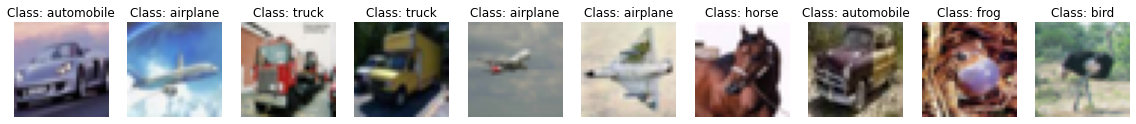

In [7]:
# 데이터 확인
batch_x, batch_y = next(iter(train_loader))

pltsize = 2
plt.figure(figsize=(10 * pltsize, pltsize))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.axis('off')
    plt.imshow(np.transpose(batch_x[i], (1, 2, 0)))
    plt.title('Class: ' + str(['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'][batch_y[i].item()]))

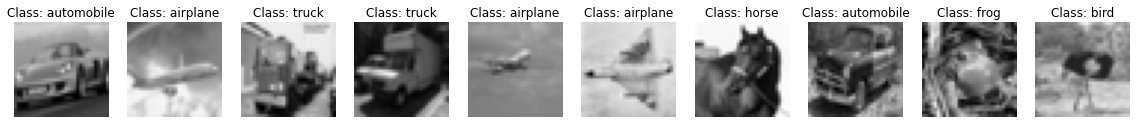

In [8]:
# data augmentation 후 결과 확인
# https://pytorch.org/vision/master/transforms.html

augment = transforms.Grayscale(num_output_channels=3)
# augment = transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5, hue=0.5)
# augment = transforms.RandomHorizontalFlip(p=0.5)
# augment = transforms.RandomVerticalFlip(p=0.5)
# augment = transforms.RandomResizedCrop((200, 200), scale=(0.1, 1), ratio=(0.5, 2))

pltsize = 2
plt.figure(figsize=(10 * pltsize, pltsize))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.axis('off')
    plt.imshow(np.transpose(augment(batch_x[i]), (1, 2, 0)))
    plt.title('Class: ' + str(['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'][batch_y[i].item()]))

In [9]:
# ----- Load Dataset with augment_transform -----

In [10]:
augment_transform = transforms.Compose([
    # transforms.Resize((224,224)),
    transforms.ColorJitter(hue=.05, saturation=.05),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20, resample=PIL.Image.BILINEAR),
    # transforms.ToTensor(), # collate_fn에 넣어주는 게 더 좋음
])

/Users/jeongmoonwon/opt/anaconda3/lib/python3.8/site-packages/torchvision/transforms/transforms.py:1230: UserWarning: Argument resample is deprecated and will be removed since v0.10.0. Please, use interpolation instead
  warnings.warn(


In [11]:
train_dataset = CustomDataset(train = True, transform = augment_transform)
test_dataset = CustomDataset(train = False, transform = augment_transform)

train_loader = DataLoader(dataset = train_dataset, 
                          batch_size = BATCH_SIZE, 
                          shuffle = True, 
                          collate_fn = train_dataset.collate_fn)

test_loader = DataLoader(dataset = test_dataset, 
                         batch_size = BATCH_SIZE, 
                         shuffle = False, 
                         collate_fn = test_dataset.collate_fn)

Files already downloaded and verified
Files already downloaded and verified


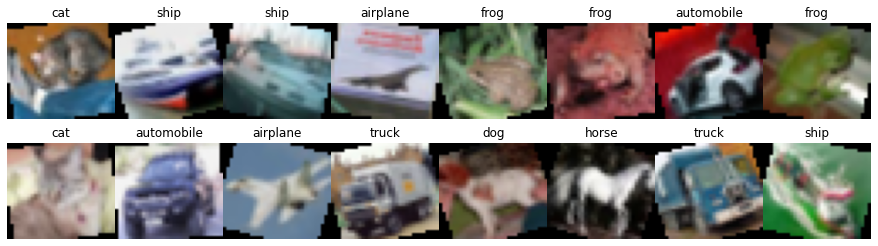

In [12]:
CIFAR_plot_dataset(test_loader)

In [13]:
# 한 epoch를 돌고, 바로 다음 epoch에 나오는 동일한 batch를 출력하기 위한 코드
for _ in range(len(test_loader)-1):
    next(iter(test_loader))
print(_) # 한 epoch에 배치가 311개가 있음. 311번 돌고 다시 처음 배치로 가기

311


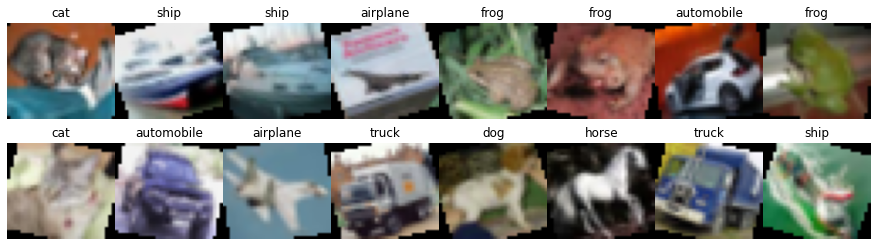

In [14]:
CIFAR_plot_dataset(test_loader)

In [15]:
# ----- Load Dataset with augment_transform / without collate_fn -----

In [16]:
transform = transforms.Compose([
    # transforms.Resize((224,224)),
    transforms.ColorJitter(hue=.05, saturation=.05),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20, resample=PIL.Image.BILINEAR),
    transforms.ToTensor(),
])

In [17]:
train_dataset = datasets.CIFAR10(root = "./data/CIFAR_10",
                                 train = True,
                                 download = True,
                                 transform = transform)

test_dataset = datasets.CIFAR10(root = ".data/CIFAR_10",
                                train = False,
                                download = True,
                                transform = transform)

train_loader = DataLoader(dataset = train_dataset,
                          batch_size = BATCH_SIZE,
                          shuffle = True)
test_loader = DataLoader(dataset = test_dataset,
                         batch_size = BATCH_SIZE,
                         shuffle = False)

Files already downloaded and verified



Extracting .data/CIFAR_10/cifar-10-python.tar.gz to .data/CIFAR_10


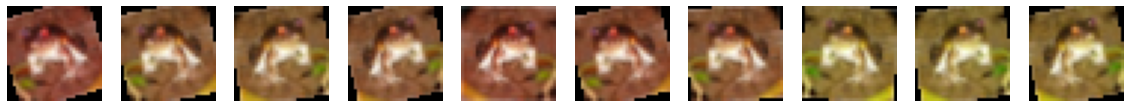

In [18]:
# 데이터 확인
pltsize = 2
plt.figure(figsize=(10 * pltsize, pltsize))

for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(np.transpose(train_dataset[0][0], (1,2,0)))
    plt.axis('off')